In [22]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')
from src.plot_helper import apply_fancy_labels,plot_grid_heatmap
def analyze_ligand_screen(vectorAll, CR_names, moleculesID):
    # ... [Same processing logic for correlation and filtering as before] ...
    # Ensure inputs are appropriate formats
    vectorAll = np.array(vectorAll)
    CR_names = np.array(CR_names)
    moleculesID = np.array(moleculesID)

    # ---------------------------------------------------------
    # 1. Identify Reference (CR518)
    # ---------------------------------------------------------
    # Find index containing '000-000-CR518'
    # Note: str.find returns -1 if not found.
    # We assume there is exactly one match as per the MATLAB logic implies
    cr518_indices = [i for i, name in enumerate(CR_names) if '000-000-CR518' in name]
    
    if not cr518_indices:
        raise ValueError("Reference '000-000-CR518' not found in CR_names")
        
    ref_idx = cr518_indices[0]
    ref_CR518_homomer = vectorAll[ref_idx, :]

    # ---------------------------------------------------------
    # 2. Pearson Correlation Loop
    # ---------------------------------------------------------
    pearson_corr = []
    
    for j in range(vectorAll.shape[0]):
        vector_j = vectorAll[j, :]
        
        # Find indices where the sum of the two vectors is not zero
        # This includes any index where at least one of them has a value
        # MATLAB: sum([ref; vec], 1) ~= 0
        sum_vec = ref_CR518_homomer + vector_j
        nonzero_idx = np.where(sum_vec != 0)[0]
        
        if len(nonzero_idx) > 1:
            # Calculate correlation only on the non-zero shared indices
            # index 0,1 gets the correlation between x and y
            corr_mat = np.corrcoef(ref_CR518_homomer[nonzero_idx], vector_j[nonzero_idx])
            val = corr_mat[0, 1]
            pearson_corr.append(val)
        else:
            pearson_corr.append(np.nan)

    pearson_corr = np.array(pearson_corr)
    
    # Sort receptors by correlation (Descending)
    # argsort is ascending, so we reverse it [::-1]
    receptorCorr_IDX = np.argsort(pearson_corr)[::-1]
    
    CRnames_sorted = CR_names[receptorCorr_IDX]

    # ---------------------------------------------------------
    # 3. Filter Ligands (Remove NaN, DMSO, Ionomycin)
    # ---------------------------------------------------------
    # MATLAB: contains(moleculesID, {'NaN','dmso', 'Ionomycin'})
    # We check if any of the bad substrings are in the molecule ID
    bad_substrings = ['NaN', 'dmso', 'Ionomycin']
    
    keep_mask = []
    for mol in moleculesID:
        is_bad = any(sub in mol for sub in bad_substrings)
        keep_mask.append(not is_bad) # Keep if NOT bad
        
    keep_mask = np.array(keep_mask)
    
    # Filter data and names
    vectorAll_noNaN = vectorAll[:, keep_mask]
    moleculesID_noNaN = moleculesID[keep_mask]
    
    # ---------------------------------------------------------
    # 4. Sort Ligands by Mean Response
    # ---------------------------------------------------------
    # Mean along axis 0 (down the columns), ignoring NaNs
    vectorAll_mean = np.nanmean(vectorAll_noNaN, axis=0)
    
    # Sort indices descending
    sortLigands_IDX = np.argsort(vectorAll_mean)[::-1]

    # 1. Prepare Data for Plot 1
    matrix_sorted_both = vectorAll_noNaN[receptorCorr_IDX, :][:, sortLigands_IDX]
    molecules_sorted = moleculesID_noNaN[sortLigands_IDX]
    CRnames_sorted = CR_names[receptorCorr_IDX]

    # Render Plot 1
    im1, ax1 = plot_grid_heatmap(matrix_sorted_both)
    apply_fancy_labels(im1, ax1, molecules_sorted, CRnames_sorted, 
                       'Normalized response (Sorted by Corr)', 
                       'Sorted by corr to CR518')

    # 2. Prepare Data for Plot 2
    matrix_sorted_ligands = vectorAll_noNaN[:, sortLigands_IDX]
    
    # Render Plot 2
    im2, ax2 = plot_grid_heatmap(matrix_sorted_ligands)
    apply_fancy_labels(im2, ax2, molecules_sorted, CR_names, 
                       'Normalized response (Unsorted Receptors)', 
                       'Receptors (Original Order)')

    plt.show()
    return receptorCorr_IDX, sortLigands_IDX

Loaded 57 Receptors and 96 Ligands.


/home/hugo/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/hugo/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


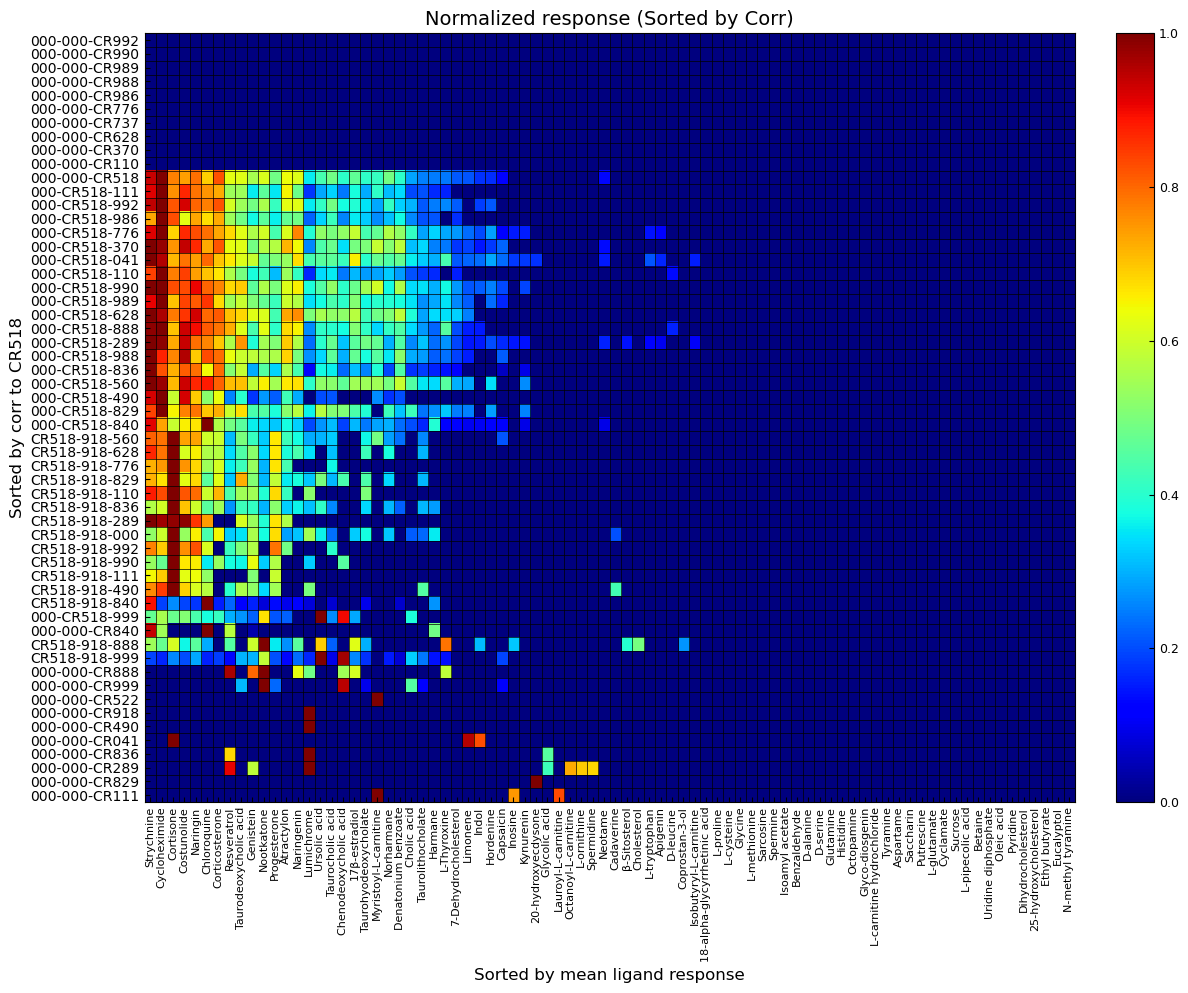

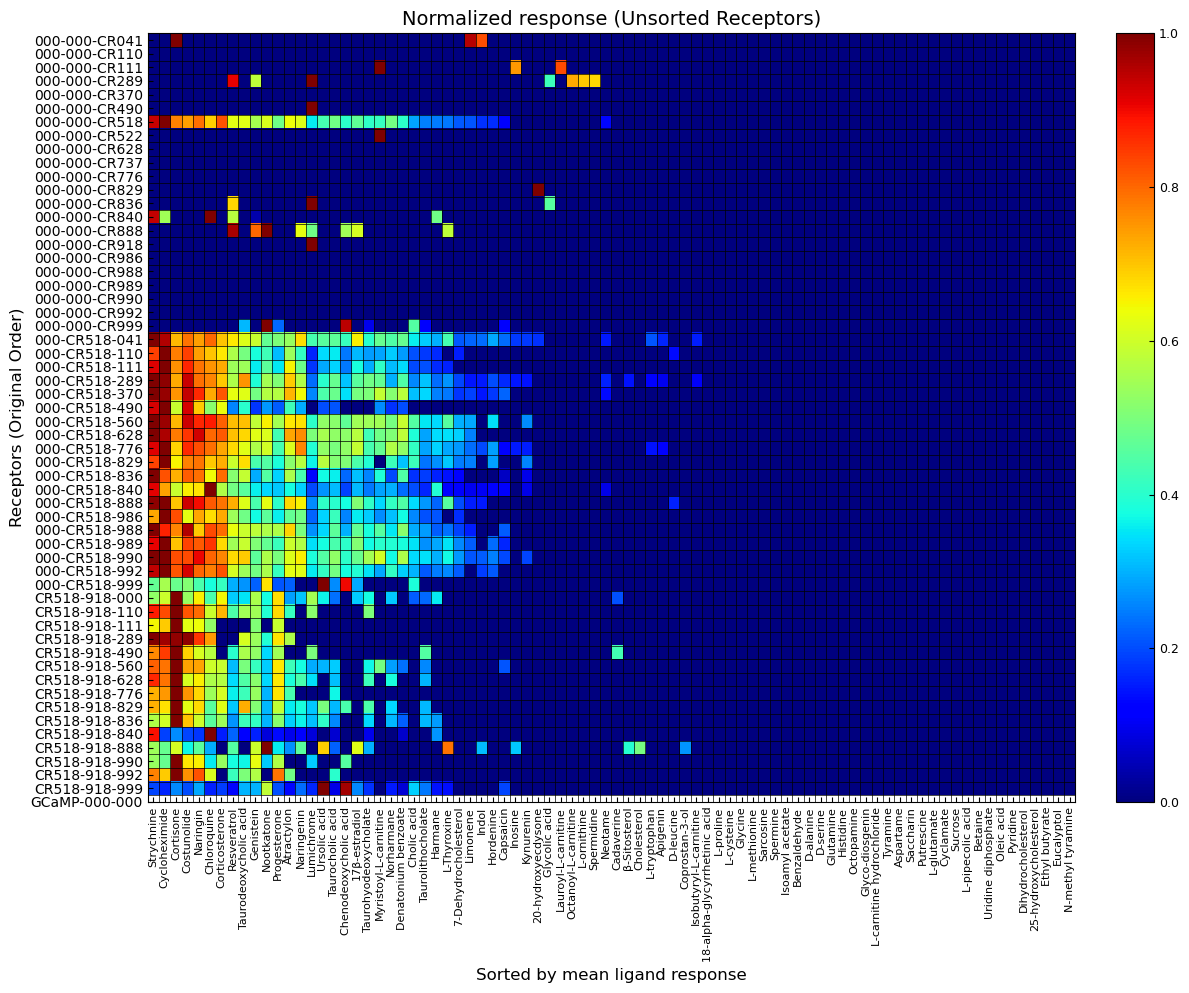

In [23]:
path = '/mnt/hcleroy/PostDoc2/octopus_smelling/experimental_data/matlab_files/v3/'
# 1. Load the .mat file
# simple_keys=True ensures we don't get complex MATLAB struct objects if possible
mat_contents = sio.loadmat(path+'ligandScreen_variables.mat', squeeze_me=True)
# 2. Extract the specific variables
# Note: 'squeeze_me=True' automatically fixes the shape (e.g., converts [[1,2,3]] to [1,2,3])
vectorAll = mat_contents['vectorAll']
vectorAll[np.isnan(vectorAll)]=0
# MATLAB cell arrays of strings often load as arrays of objects or strings.
# We force them to be a standard list/array of strings for Python.
CR_names = mat_contents['CR_names']
moleculesID = mat_contents['moleculesID']

# Handle cases where single-element MATLAB arrays become scalars
if CR_names.ndim == 0: CR_names = np.array([CR_names])
if moleculesID.ndim == 0: moleculesID = np.array([moleculesID])

# 3. Clean up string formatting (Optional but recommended)
# Sometimes MATLAB strings load with extra whitespace
CR_names = [str(name).strip() for name in CR_names]
moleculesID = [str(name).strip() for name in moleculesID]

# 4. Run the analysis
print(f"Loaded {len(CR_names)} Receptors and {len(moleculesID)} Ligands.")
analyze_ligand_screen(vectorAll, CR_names, moleculesID)
pass


# Compute the mutual information

In [3]:
from scipy.special import entr
import sys
sys.path.append('../..')
from src.receptor_information import compute_mi

In [4]:
def get_mi(activity_array,n_bins):
    """
    activity array: np.ndarray : shape (receptors,ligands)

    """
    # define the bins:
    # activity bins
    bins = np.linspace(0,1,n_bins)
    binned_A = bins[np.digitize(activity_array,bins)-1]
    # The compute_mi function expect (L, Nr, Nc).
    # Current shape is (Nr, L). We need to:
    # 1. Transpose to (L, Nr) -> (96, 56)
    # 2. Add the 3rd dimension 'Nc' (which is 1 if you have 1 conc/replicate)
    # Final shape: (96, 56, 1)
    formatted_binned_A = binned_A.T[:, :, np.newaxis] 
    # compute mi
    return compute_mi(formatted_binned_A)


In [5]:
print(f"Mutual Information: {get_mi(vectorAll,2):.4f} nats")
print(f"Theoretical Max (log(L)): {np.log(vectorAll.shape[1]):.4f} nats")

Mutual Information: 0.5171 nats
Theoretical Max (log(L)): 4.5643 nats


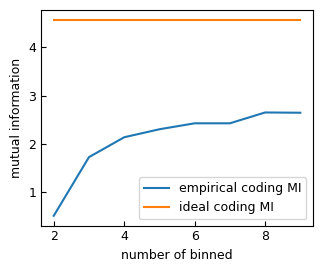

In [6]:
mi = np.array([get_mi(vectorAll,nbins)for nbins in np.arange(2,10,1)])
x = np.arange(2,10,1)
plt.plot(x,mi,label='empirical coding MI')
plt.plot([2,9],[np.log(vectorAll.shape[1]),np.log(vectorAll.shape[1])],label='ideal coding MI')

plt.xlabel("number of binned")
plt.ylabel("mutual information")
plt.legend()

In [7]:
path = '/mnt/hcleroy/PostDoc2/octopus_smelling/experimental_data/matlab_files/v3/'
# 1. Load the .mat file
# simple_keys=True ensures we don't get complex MATLAB struct objects if possible
mat_contents = sio.loadmat(path+'ligandScreen_variables.mat', squeeze_me=True)


In [31]:
vector_homo = mat_contents['vectorAll'][:22]
vector_homo[np.isnan(vector_homo)]=0
CR_names_homo = mat_contents['CR_names'][:22]
moleculesID = np.array(mat_contents['moleculesID'])

# Handle cases where single-element MATLAB arrays become scalars
if CR_names_homo.ndim == 0: CR_names_homo = np.array([CR_names_homo])
if moleculesID.ndim == 0: moleculesID = np.array([moleculesID])

# 3. Clean up string formatting (Optional but recommended)
# Sometimes MATLAB strings load with extra whitespace
CR_names_homo = [str(name).strip() for name in CR_names_homo]
moleculesID = np.array([str(name).strip() for name in moleculesID])

# ---------------------------------------------------------
# 3. Filter Ligands (Remove NaN, DMSO, Ionomycin)
# ---------------------------------------------------------
# MATLAB: contains(moleculesID, {'NaN','dmso', 'Ionomycin'})
# We check if any of the bad substrings are in the molecule ID
bad_substrings = ['NaN', 'dmso', 'Ionomycin']

keep_mask = []
for mol in moleculesID:
    is_bad = any(sub in mol for sub in bad_substrings)
    keep_mask.append(not is_bad) # Keep if NOT bad
    
keep_mask = np.array(keep_mask)

# Filter data and names
vector_homo = vector_homo[:, keep_mask]
moleculesID = moleculesID[keep_mask]

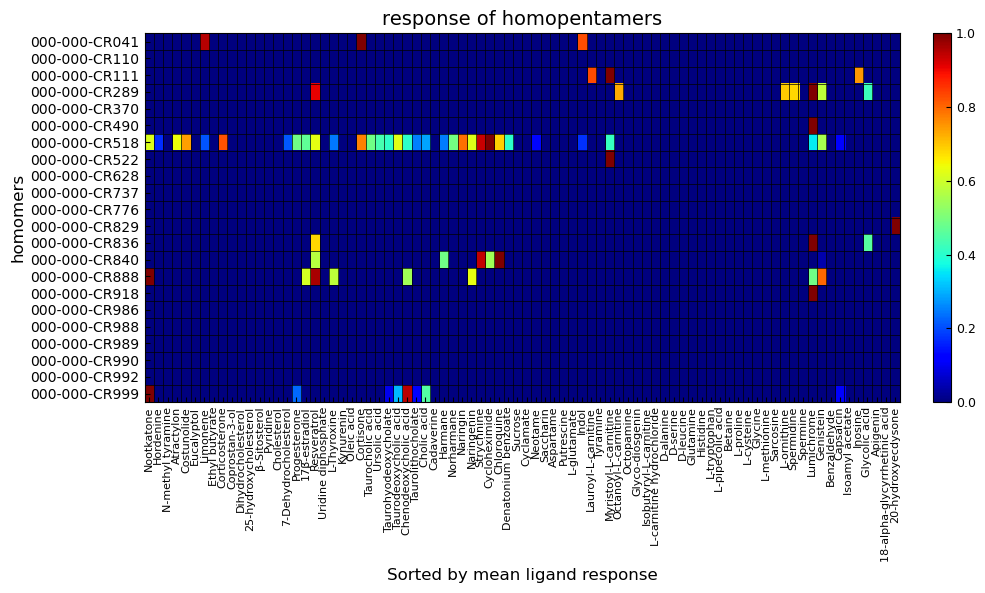

In [32]:
im,ax = plot_grid_heatmap(vector_homo,figsize=(10,6))
apply_fancy_labels(im,ax,moleculesID,CR_names_homo,'response of homopentamers','homomers')

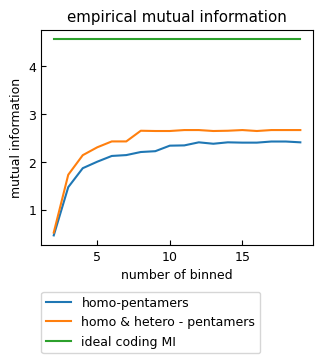

In [ ]:
bins = np.arange(2,20,1)
mi_homo = np.array([get_mi(vector_homo,nbins)for nbins in bins])
mi_homo_p_hetero = np.array([get_mi(vectorAll,nbins)for nbins in bins])

plt.plot(bins,mi_homo,label='homo-pentamers')
plt.plot(bins,mi_homo_p_hetero,label='homo & hetero - pentamers')

plt.plot([bins[0],bins[-1]],[np.log(vectorAll.shape[1]),np.log(vectorAll.shape[1])],label='ideal coding MI')

plt.xlabel("number of bins")
plt.ylabel("mutual information")
plt.title("empirical mutual information")
plt.legend(loc=(0,-0.5))